In [1]:
# TODO make sure this renders in the github repo

# Pre-Training An LLM

💡 **For the Llama 3.1 architecture, which is text-only!**


🌟 **LLM training occurs in two phases:**

1. **Pre-Training** (Phase 1):
    - Objective: (Teacher Forcing) Next-Token prediction over a massive, unstructured dataset (trillions of words from the internet, books, code).
    - Note: The pre-training phase is the most expensive part of training an LLM.
    - Goal: To teach the model the structure of human language, logic, coding syntax, and general world knowledge. This is the base model.
    - Steps:
        1. Pass a input sequence of tokens through the model.
            - The tokens are masked so the model can not see future tokens, and specific to Llama, a document mask that prevents a token from one document from attending to tokens in other documents.
            - The ground truth is the same as the input, but shifted right by one token.
        2. The models outputs a prediction for every position at once, and we calculate cross-entropy loss between the model's prediction and the ground truth.

2. [**Post-Training** (Phase 2)](./post_training.ipynb)

---

**Llama 3 paper:**

- "We start by converting a large, multilingual text corpus to discrete tokens and pre-training a large language model (LLM) on the resulting data to perform next-token prediction. In the language model pre-training stage, the model learns the structure of language and obtains large amounts of knowledge about the world from the text it is “reading”. To do this effectively, pre-training is performed at massive scale: we pre-train a model with $405B$ parameters on $15.6T$ tokens using a context window of $8K$ tokens. This standard pre-training stage is followed by a continued pre-training stage that increases the supported context window to $128K$ tokens. See Section 3 for details."
- "The recipe used to **pre-train Llama 3 405B** consists of three main stages: **(1) initial pre-training, (2) long-context pre-training, and (3) annealing**. The three stages are described separately below. We use similar recipes to pre-train the 8B and 70B models."
    - **Sub Pre-training stages:** (A single pre-training run)
        1. **Initial**: Most of pre-training is spent on this stage. Trains a massive, diverse mix of data (e.g., $15.6$ Trillion Tokens), using the standard learning rate schedule, and a **shorter context window** ($8{,}192$ tokens was used for the Llama 3). A shorter context window during this sub stage keeps the cost to train lower. Paper: "3.4.1 Initial Pre-Training ... We pre-train Llama 3 405B using AdamW ... Specifically, we use an initial batch size of 4M tokens and sequences of length 4,096, and double these values to a batch size of 8M sequences of 8,192 tokens after pre-training 252M tokens."
        2. **Long-Context:** Once the model has understand language from the initial stage, they **gradually increased the context window** from $8{,}192$ tokens to $128K$ tokens. This is done because the model has learned how to predict words, it just needed to learn how to look further back in its memory to do it. Paper: "In Llama 3 405B pre-training, we increased context length gradually in six stages, starting from the original 8K context window and ending in the final 128K context window. This long-context pre-training stage was performed using approximately 800B training tokens."
        3. **Annealing:** Decayed the learning rate to $0$ past the `min_lr_ratio`, change the data mix to the absolute highest quality math and reasoning data sources. Paper source: "During pre-training on the final $40M$ tokens, we linearly annealed the learning rate to 0, maintaining a context length of $128K$ tokens. During this annealing phase, we also adjusted the data mix to upsample data sources of very high quality; see Section 3.1.3. Finally, we compute the average of model checkpoints (Polyak (1991) averaging) during annealing to produce the final pre-trained model."


**Notes:**

- Instead of training on a **number of epochs**, the LLMs are trained on a **number of steps**. Once it reaches the **total_training_steps** (e.g., 1,200,000), training ends. This is done because the datasets for LLM training are so massive, that the model will rarely see the same piece of text twice.
- The dataloader yields dense, packed batches of tokens.
- **Gradient Accumulation:** A technique that allows you to simulate a large **Global Batch Size** even when your hardware, i.e, GPU VRAM can only fir a small **Micro-batch Size**.


💡 **Token Budget/Dataset Size:**

- In LLM, data is not measured in gigabytes, sentence pairs, or epochs. Compute and training length are measured in tokens. The token budget dictates the maximum number of tokens you want the model to process before training terminates:

$$\text{Token Budget} = \text{Global Batch Size(in tokens)} * \text{Total Training Steps}$$

- Example: $\text{Token Budget} = 1.5 \text{Billion}$ tokens, and your hardware can handle a $\text{Global Batch Size}$ of $500{,}000$ tokens per step, then: $1.5 \text{Billion} / 500{,}000 = 3{,}000$ total training steps.

**Total Training Steps**: The number of times the model's weights are updated.
**Gradient Accumulation**: Allows us to perform multiple forward and backward passes, but instead of updating the weights immediately, we **accumulate** the gradients over **several steps**. Only after the specified number of `accumulation steps` do we trigger the optimizer to update the weights. This means we can simulate a massive Global Batch Size that would otherwise not fit in your hardware's VRAM.

- **Global Batch Size**: The total number of tokens the optimizer needs to look at together to calculate an accurate gradient. $\text{Global Batch Size} = \text{Micro Batch Size} \times \text{Number of GPUs} \times \text{Accumulation Steps}$
- **Micro Batch Size:** The number of sequences your hardware can hold in its VRAM (GPU Memory) during a single forward and backward pass.
    - Example: `micro_batch_size` $=4$ and `context_len` $=4{,}096$ a single batch will contain $4*4{,}096 = 16{,}384 \, \text{tokens}$ per GPU.
- To ensure the accumulated gradients are equivalent to a gradient calculated from one large global batch, we **scaled the loss**, this prevents the gradients from exploding. $\text{Scaled Loss} = \text{Loss} / \text{Accumulation Steps}$


In [2]:
import easyjupyter
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from pathlib import Path

In [3]:
from typing import TYPE_CHECKING

if TYPE_CHECKING:
    from llama_configs import BaseConfig
    from model.decoder import Decoder

## Validation


Llama 3 paper: "Empirically, we find that annealing (see Section 3.4.3) on small amounts of high-quality code and mathematical data can boost the performance of pre-trained models on key benchmarks. Akin to Li et al. (2024b), we perform annealing with a data mix that upsamples high-quality data in select domains. We do not include any training sets from commonly used benchmarks in our annealing data. This enables us to assess the true few-shot learning capabilities and out-of-domain generalization of Llama 3. Following OpenAI (2023a), **we evaluate the efficacy of annealing on the GSM8k (Cobbe et al., 2021) and MATH (Hendrycks et al., 2021b) training sets in annealing.** We find that **annealing improved the performance** of a pre-trained Llama 3 8B model on the GSM8k and MATH validation sets by 24.0% and 6.4%, respectively. However, the improvements on the 405B model are negligible, suggesting that our flagship model has strong in-context learning and reasoning capabilities and does not require specific in-domain training samples to obtain strong performance."


## Loss Function


**Llama 3 Paper:**

- "Language model **pre-training**. **We start by converting a large, multilingual text corpus to discrete tokens and pre-training a large language model (LLM) on the resulting data to perform next-token prediction.** **In the language model pre-training stage, the model learns the structure of language and obtains large amounts of knowledge about the world from the text it is “reading”.** To do this effectively, pre-training is performed at massive scale: we pre-train a model with 405B parameters on 15.6T tokens using a context window of 8K tokens. This standard pre-training stage is followed by a continued pre-training stage that increases the supported context window to 128K tokens. See Section 3 for details."

**Notes:**

- **Cross-Entropy Loss** was used for the **Pre-Training** (to calculate the error of next-token prediction compared to the ground truth) and in the SFT portion of **Post-Training**. **DPO Loss** is used in the alignment/Direct Preference Optimization portion of **Post-Training**.


## Pre-Training


[Optimizer and Scheduler](./utils/optimizer_and_scheduler.ipynb)


In [4]:
from dataclasses import dataclass

@dataclass
class PreTrainStage:
    name: str
    start_step: int
    end_step: int
    bin:str # initial_and_lc_stage.bin or annealing_stage.bin
    context_len: int

In [5]:
import time
from datetime import datetime, timedelta
from model.utils.model_io import save_checkpoint
from model.utils.plot import plot_loss_history
from model.utils.masking import create_causal_doc_mask
from typing import TYPE_CHECKING
from model.data_loader import create_pretrain_dataloader

if TYPE_CHECKING:
    from torch.optim.lr_scheduler import LambdaLR
    import torch.optim as optim
    from model.model_text_only import TextOnlyModel


class PreTrainTextOnly:
    def __init__(
        self,
        cfg: BaseConfig,
        model: TextOnlyModel,
        optimizer: optim.AdamW,
        scheduler: LambdaLR,
        is_overfit: bool = False,
    ):
        """
        Implements pre-training.
        """

        self.cfg = cfg
        self.model = model
        self.is_overfit = is_overfit
        self.stages = self._build_stages()

        self.criterion = nn.CrossEntropyLoss(
            ignore_index=cfg.special_tokens["pad_token"]["ID"],
        )
        self.optimizer = optimizer
        self.scheduler = scheduler

        # Track the training steps. Once it reach `total_training_steps` training ends.
        self.step_counter = cfg.step_counter
        self.loss_history = []
        self.start_time = None  # Track the start time of the training

        # Exponential Moving Average printing for step time
        self.alpha = 0.1
        self.ema_step_time = None
        self.last_print_time = None

        self.increase_context_len_steps_tracker = 0
        self.initial_duration = int(
            cfg.pre_training_stages_steps["initial_perc"] * cfg.total_training_steps
        )
        self.lc_duration = int(
            cfg.pre_training_stages_steps["long_context_perc"]
            * cfg.total_training_steps
        )
        self.lc_start_step = self.initial_duration
        self.annealing_start_step = self.lc_start_step + self.lc_duration

        self.cfg.training_stage = "pre-trained"

    def train(
        self,
        overfit=False,
        print_every: int = 100,
        is_dry_run: bool = False,
    ):
        """
        Pre-train the model.
        Args:
            overfit: Whether to do a small overfit test.
            print_every: Print every n steps.
        """
        print("\n" + "#" * 64)
        print(
            f"\nPre-Training Model | Total Training Steps: {self.cfg.total_training_steps:,} | "
            f"Accumulation Steps: {self.cfg.gradient_accumulation_steps}"
        )
        print("\n" + "#" * 64)

        # TODO Add a validation loop to validate while training Maybe take a slice of the coming dataset and set it to the validation set every n steps and then that n steps run the validation loop, maybe set n steps to be the same as save config interval

        self.model.train()  # Set the model to train mode

        current_bin = self.restore_substage_state()

        dataloader = create_pretrain_dataloader(
            self.cfg, bin_path=current_bin, start_step=self.step_counter
        )
        data_iter = iter(dataloader)
        grad_accum_steps = self.cfg.gradient_accumulation_steps

        if overfit:
            # Setup a single batch of data for overfitting
            self.static_x, self.static_y = next(data_iter)

        self.start_time = time.time()
        self.last_print_time = self.start_time

        while self.step_counter < self.cfg.total_training_steps:

            # Handle Pre-training sub-stage transitions: (1) Initial -> (2) Long-Context -> (3) Annealing
            grad_accum_steps, dataloader, data_iter = self._handle_stage_transitions(
                grad_accum_steps, dataloader, data_iter, overfit
            )

            avg_loss, data_iter = self._train_step(
                grad_accum_steps, dataloader, data_iter, overfit
            )

            self.loss_history.append(avg_loss)
            self.step_counter += 1

            self._print_step_info(
                avg_loss=avg_loss,
                print_every=1 if is_dry_run else print_every,
            )

            # Exit early for dry runs
            if is_dry_run and self.step_counter >= 5:
                print("\nDry Run Complete!")
                self._save_checkpoint(avg_loss)
                break

            if self.step_counter % 200 == 0 and not overfit:
                # Save a checkpoint every 200 steps
                self._save_checkpoint(avg_loss)

        if not is_dry_run:
            self._save_checkpoint(avg_loss)
            print("\nTraining complete!\n")

    def _run_micro_batch(self, x_ids, y_ids, grad_accum_steps):
        """
        Run a single forward and backward pass for a micro-batch using the micro batch size.

        Args:
            x_ids: The input token ids.
            y_ids: The output token ids.
        """

        # Generated the doc and causal mask
        batch_mask = create_causal_doc_mask(cfg=self.cfg, token_ids=x_ids)

        # Forward pass
        logits, _ = self.model(x_ids, batch_mask)

        # Compute the loss
        loss = self.criterion(
            logits.view(-1, self.cfg.vocab_size), y_ids.view(-1)
        )  # Flatten to 2D and 1D for CrossEntropy

        # Scale the loss to account for gradient accumulation
        scaled_loss = loss / grad_accum_steps

        # Backward pass
        scaled_loss.backward()

        # Return the unscaled loss
        return loss.item()

    def _print_step_info(self, avg_loss, print_every):
        if self.step_counter % print_every == 0:
            curr_time = time.time()

            # Calculate time taken for just the last `print_every` steps
            internal_time = curr_time - self.last_print_time
            actual_step_time = internal_time / print_every

            # Update Exponential Moving Average
            if self.ema_step_time is None:
                self.ema_step_time = actual_step_time
            else:
                self.ema_step_time = (self.alpha * actual_step_time) + (
                    1 - self.alpha
                ) * self.ema_step_time

            remaining_steps = self.cfg.total_training_steps - self.step_counter
            eta_seconds = self.ema_step_time * remaining_steps

            eta_str = str(timedelta(seconds=int(eta_seconds)))
            elapsed_str = str(timedelta(seconds=int(curr_time - self.start_time)))

            print(
                f"[{datetime.now().strftime('%m-%d %H:%M:%S')}] | "
                f"Step [{self.step_counter}/{self.cfg.total_training_steps}] | "
                f"Avg Step: {self.ema_step_time:.2f} | "
                f"Elapsed: {elapsed_str} | "
                f"ETA: {eta_str} | "
                f"Loss: {avg_loss:.4f} "
            )
            self.last_print_time = curr_time

    def _handle_stage_transitions(
        self, grad_accum_steps, dataloader, data_iter, overfit=False
    ):
        """
        Called every step. Handles sub-stage transitions -> Pre-training stages: (1) Initial, (2) Long-Context, (3) Annealing
        """
        if overfit:
            return grad_accum_steps, dataloader, data_iter

        for stage in self.stages:
            if self.step_counter == stage.start_step and stage.name != "initial":
                self.cfg.update_context_len(stage.context_len)
                print(
                    f"\n[Stage Transition] -> {stage.name} | "
                    f"context_len: {stage.context_len} | "
                    f"grad_accum_steps: {grad_accum_steps}"
                )
                dataloader, data_iter = self._refresh_dataloader(
                    bin_path=self.cfg.DATA_DIR / stage.bin
                )
                break
        return grad_accum_steps, dataloader, data_iter

    def restore_substage_state(self) -> Path:
        """Called once after loading a checkpoint to resume training. This restores context_len and returns the correct bin to the one that checkpoint was lasted trained on"""
        stage = self._get_current_stage()
        self.cfg.update_context_len(stage.context_len)
        print(
            f"\n[Pipeline State] Stage: {stage.name} | "
            f"Step: {self.step_counter} | "
            f"context_len: {stage.context_len} | "
            f"bin: {stage.bin}"
        )
        return self.cfg.DATA_DIR / stage.bin

    def _save_checkpoint(self, avg_loss):
        self.cfg.step_counter = self.step_counter

        save_checkpoint(
            cfg=self.cfg,
            model=self.model,
            optimizer=self.optimizer,
            scheduler=self.scheduler,
            step_counter=self.step_counter,
            loss_history=self.loss_history,
            avg_loss=avg_loss,
        )

        self.cfg.save_config_to_json()
        plot_loss_history(
            cfg=self.cfg, loss_history=self.loss_history, step_counter=self.step_counter
        )

    def _refresh_dataloader(self, bin_path):
        """Re-instantiate the dataloader with the updated context length or swap datasets."""
        new_dataloader = create_pretrain_dataloader(
            cfg=self.cfg, bin_path=bin_path, start_step=self.step_counter
        )
        return new_dataloader, iter(new_dataloader)

    def _train_step(self, grad_accum_steps, dataloader, data_iter, overfit=False):
        """Train a single step."""
        # NOTE: If you are training on massive GPU clusters, use HuggingFace's Accelerator for gradient accumulation!
        accumulated_loss = 0.0

        # === Inner loop: Accumulate gradients
        for micro_step in range(grad_accum_steps):
            if overfit:
                x_ids, y_ids = self.static_x, self.static_y
            else:
                try:
                    # Fetch exactly one micro-batch
                    x_ids, y_ids = next(data_iter)
                except StopIteration:
                    # Reset the iterator when exhausted
                    data_iter = iter(dataloader)
                    x, y = next(data_iter)

            x_ids = x_ids.to(self.cfg.device)
            y_ids = y_ids.to(self.cfg.device)

            # Run micro-batch, and do not call optimizer.step() there!
            loss = self._run_micro_batch(x_ids, y_ids, grad_accum_steps)
            accumulated_loss += loss

        # === Outer loop: The global step
        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

        # Apply the accumulated gradients to the weights
        self.optimizer.step()
        if not overfit:
            self.scheduler.step()
        self.optimizer.zero_grad()

        return (accumulated_loss / grad_accum_steps), data_iter

    def _build_stages(self) -> list[PreTrainStage]:
        """Build the pre-training sub-stages."""
        total = self.cfg.total_training_steps
        percs = self.cfg.pre_training_stages_steps

        initial_end = int(total * percs["initial_perc"])
        lc_end = int(total * (percs["initial_perc"] + percs["long_context_perc"]))
        annealing_end = total

        self.lc_duration = lc_end - initial_end
        # Gradually increase the context length during the long-context stage in 6 intervals
        steps_per_interval = self.lc_duration // 6
        context_step = (self.cfg.max_context_len - self.cfg.initial_context_len) // 6

        prefix = "overfit_" if self.is_overfit else ""
        initial_lc_bin = f"{prefix}initial_and_lc_stage.bin"
        anneal_bin = f"{prefix}annealing_stage.bin"


        stages = [
            PreTrainStage(
                "initial",
                0,
                initial_end,
                initial_lc_bin,
                self.cfg.initial_context_len,
            )
        ]

        # Add 6 intervals to the long-context stage
        for i in range(6):
            stages.append(
                PreTrainStage(
                    name=f"lc_{i+1}",
                    start_step=initial_end + (i * steps_per_interval),
                    end_step=initial_end + ((i + 1) * steps_per_interval),
                    bin=initial_lc_bin,
                    context_len=self.cfg.initial_context_len + (context_step * (i + 1)),
                )
            )

        # Add the final Annealing stage
        stages.append(
            PreTrainStage(
                name="annealing",
                start_step=lc_end,
                end_step=annealing_end,
                bin=anneal_bin,
                context_len=self.cfg.max_context_len,
            )
        )

        return stages

    def _get_current_stage(self) -> PreTrainStage:
        """Retrieves the current pre-training stage."""
        current = self.stages[0]
        for stage in self.stages:
            if self.step_counter >= stage.start_step:
                current = stage
        return current

/Users/tonyavis/miniconda3/envs/build_an_llm/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from model.utils.optimizer_and_scheduler import get_optimizer, get_scheduler
from model.utils.model_io import load_checkpoint

In [7]:
def setupPreTraining(
    cfg: BaseConfig,
    model: TextOnlyModel,
    chpt_path: Path = None,
    is_transition: bool = False,
    is_overfit: bool = False,
    is_dry_run: bool = False,
):
    print("\n-------- Setting Up Pre-Training For The Text-Only Model... --------")

    if is_transition is False:
        # Load the model's weights and optimizer, and scheduler.

        # TODO the optimizer and scheduler are heavily coupled I have to first load a base version then load it again when loading the checkpoint
        opt = get_optimizer(cfg, model)
        sch = get_scheduler(cfg, optimizer=opt)
        load_checkpoint(cfg, model, chpt_path, optimizer=opt, scheduler=sch)
    else:
        # Start a fresh pretrain phase
        opt = get_optimizer(cfg, model)
        sch = get_scheduler(cfg, optimizer=opt)

    prefix = ""
    if is_overfit:
        prefix = "overfit_"
    elif is_dry_run:
        prefix = "dry_run_"

    target_bin = f"{prefix}initial_and_lc_stage.bin"

    # Make sure that the binary dataset exists
    if not (cfg.DATA_DIR / target_bin).exists():
        raise FileNotFoundError(
            f"\nBinary dataset (initial_and_lc_stage.bin & annealing_stage.bin) not found at {cfg.DATA_DIR}"
            f"Please run `python prepare_data.py --d pretrain` before training."
        )

    return PreTrainTextOnly(cfg=cfg, model=model, optimizer=opt, scheduler=sch, is_overfit=is_overfit, is_dry_run=is_dry_run)

## OVERFIT TEST

`Run this to create the binary dataset`

```bash
python prepare_data.py --d pretrain --overfit
```

In [8]:
# @i-c
from llama_configs import Llama3_scaled_down
from model.model_text_only import TextOnlyModel
from model.utils.optimizer_and_scheduler import get_optimizer, get_scheduler

print("\n ---------- OVERFIT TEST ---------- \n")
cfg = Llama3_scaled_down()

# Temporarily override gradient accumulation to 1 for direct updates, needed for overfitting test
cfg.gradient_accumulation_steps = 1
max_docs = cfg.overfit_max_docs
cfg.token_budget = 250 * cfg.global_batch_size_tokens
cfg.warmup_steps = 10
cfg.CURR_CHPT_DIR = cfg.CHPTS_DIR / "Scaled_down_Llama_3_1_OVERFIT"
cfg.CURR_CHPT_DIR.mkdir(parents=True, exist_ok=True)

model = TextOnlyModel(cfg).to(cfg.device)
optimizer = get_optimizer(cfg, model=model)
scheduler = get_scheduler(cfg, optimizer=optimizer)

target_bin = "overfit_initial_and_lc_stage.bin"
# Make sure that the binary dataset exists
if not (cfg.DATA_DIR / target_bin).exists():
    raise ValueError(
        f"Binary dataset {target_bin} does not exist.\n"
        "Please run `python prepare.py --d pretrain --overfit` first."
    )

# Override learning rate to bypass warmup for direct overfitting updates
for param_group in optimizer.param_groups:
    param_group["lr"] = 1e-3 # Huge learning rate steps to force the loss down quickly

trainer = PreTrainTextOnly(
    cfg,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    is_overfit=True,
)


 ---------- OVERFIT TEST ---------- 


Project Root: /Users/tonyavis/Main/Build_an_LLM


Model initialized with 99,528,704 parameters!




Took about **~1 mins** to run the overfit test on my M1 Mac Max with 64GB RAM.

If the loss approaches 0.0, the model architecture and gradient flow are functional.


################################################################

Pre-Training Model | Total Training Steps: 250 | Accumulation Steps: 1

################################################################

[Updated Context Length] context_len: 256 | grad_accum: 1

[Pipeline State] Stage: initial | Step: 0 | context_len: 256 | bin: overfit_initial_and_lc_stage.bin


/Users/tonyavis/miniconda3/envs/build_an_llm/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[05-16 21:55:50] | Step [25/250] | Avg Step: 0.40 | Elapsed: 0:00:10 | ETA: 0:01:30 | Loss: 2.9526 
[05-16 21:55:56] | Step [50/250] | Avg Step: 0.39 | Elapsed: 0:00:16 | ETA: 0:01:17 | Loss: 0.0106 
[05-16 21:56:02] | Step [75/250] | Avg Step: 0.37 | Elapsed: 0:00:21 | ETA: 0:01:05 | Loss: 0.0049 
[05-16 21:56:08] | Step [100/250] | Avg Step: 0.36 | Elapsed: 0:00:27 | ETA: 0:00:53 | Loss: 0.0046 
[05-16 21:56:14] | Step [125/250] | Avg Step: 0.35 | Elapsed: 0:00:33 | ETA: 0:00:43 | Loss: 0.0045 
[05-16 21:56:20] | Step [150/250] | Avg Step: 0.33 | Elapsed: 0:00:39 | ETA: 0:00:33 | Loss: 0.0045 
[05-16 21:56:26] | Step [175/250] | Avg Step: 0.33 | Elapsed: 0:00:45 | ETA: 0:00:24 | Loss: 0.0044 
[05-16 21:56:32] | Step [200/250] | Avg Step: 0.32 | Elapsed: 0:00:51 | ETA: 0:00:15 | Loss: 0.0044 
[05-16 21:56:38] | Step [225/250] | Avg Step: 0.31 | Elapsed: 0:00:57 | ETA: 0:00:07 | Loss: 0.0044 
[05-16 21:56:43] | Step [250/250] | Avg Step: 0.30 | Elapsed: 0:01:03 | ETA: 0:00:00 | Loss: 0

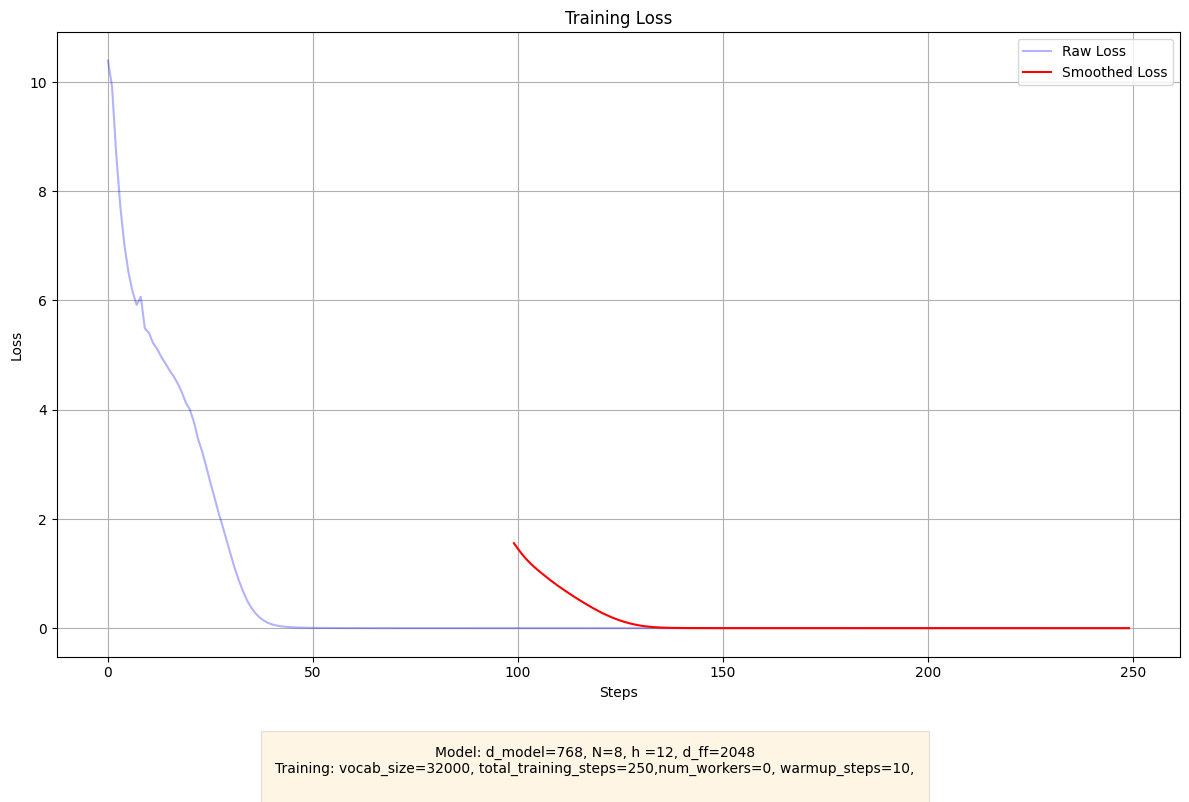


Training complete!



In [9]:
# @i-c:
print(
    "If the loss approaches 0.0, the model architecture and gradient flow are functional.\n"
)
trainer.train( overfit=True, print_every=25)